# Image Reconstruction

<h2> <b> Reconstructing the image</b></h2>

The image is encoded by the "Encoder" part of the CNNAutoencoder in the notebook <i>"representations.ipynb"</i>. The "Decoder" of the same trained model is then used to decode the image representations and re-create the image.

In this notebook, 5 random images are first encoded and then decoded, thus demonstrating the working of CNNAutoencoder.

### <b>Data Loading and pre-processing</b>

In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
# setting up seed
seed = 42
torch.manual_seed(seed=seed)
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(42)

# 4. Force PyTorch to use deterministic algorithms
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seeds locked to {seed}. Training is now reproducible.")


Random seeds locked to 42. Training is now reproducible.


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Subset, DataLoader

In [17]:
# 1. define the transformation
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Load the Tiny ImageNet dataset from Hugging Face
from datasets import load_dataset
ds = load_dataset("zh-plus/tiny-imagenet")

test_dataset = ds["valid"].shuffle(seed=42).select(range(1000))

# 4. Preprocessing transform function (Only returns what the model needs)
def preprocess(examples):
    return {
        "pixel_values": [transform(img.convert("RGB")) for img in examples["image"]],
        "label": examples["label"]
    }

test_dataset_transformed = test_dataset.with_transform(preprocess)


test_loader = DataLoader(test_dataset_transformed, batch_size=64, shuffle=False)

# 7. Verify sizes
print(f"Data loading complete:")
print(f" - Test samples:  {len(test_dataset)}")


c:\Users\mpune\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\mpune\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\mpune\.cache\huggingface\hub\datasets--zh-plus--tiny-imagenet. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an 

Data loading complete:
 - Test samples:  1000


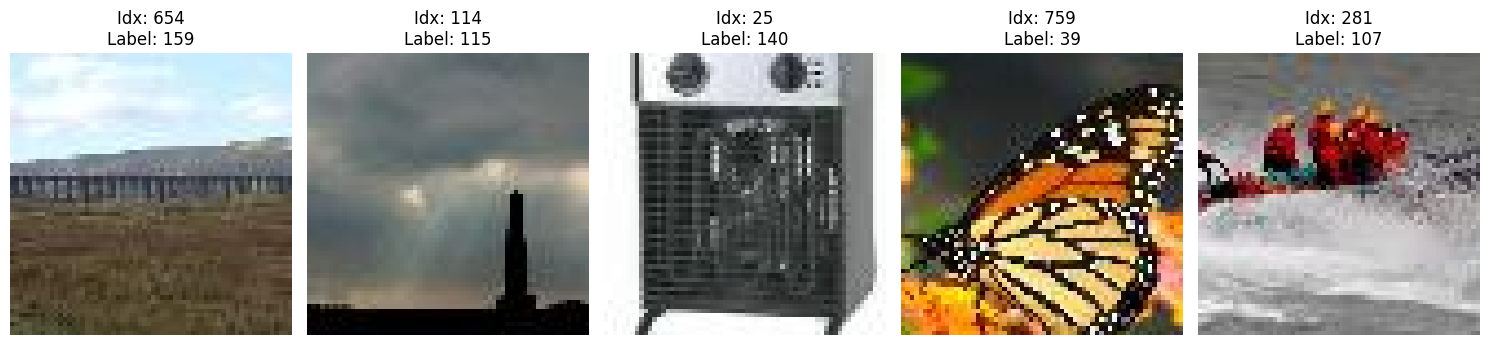

In [18]:
import random

# Set the seed for reproducibility
random.seed(seed)

# 1. Get 5 random indices from the training dataset
# Use train_dataset_transformed to ensure we get preprocessed tensors
random_indices = random.sample(range(len(test_dataset_transformed)), 5)

# 2. Denormalization parameters (matching the transform's mean and std)
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

# 3. Plot the de-normalized images
plt.figure(figsize=(15, 5))
for i, idx in enumerate(random_indices):
    # This retrieves the preprocessed sample (dict containing 'pixel_values' tensor and 'label')
    sample = test_dataset_transformed[idx]
    img = sample['pixel_values'].cpu()

    # De-normalize the tensor back to the original pixel range [0, 1]
    img = img * std + mean

    # Convert shape from (C, H, W) to (H, W, C) for Matplotlib
    img = img.numpy().transpose((1, 2, 0))
    img = np.clip(img, 0, 1) # Clip values to keep them in valid [0, 1] range

    label = sample['label']

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Idx: {idx}\nLabel: {label}")
    plt.axis('off')

plt.tight_layout()
plt.show()


### <b>The Autoencoder</b>

In [19]:
class CNNAutoencoder(nn.Module):
    def __init__(self):
        super(CNNAutoencoder, self).__init__()
        # ====================================
        # THE ENCODER
        # Input shape: [Batch, 3, 64, 64]
        # ====================================

        self.encoder = nn.Sequential(
            # Layer 1: 3 channels -> 16 channels, size halves to 32 x 32
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(True),

            # Layer 2: 16 channels -> 32 channels, size halves to 16 x 16
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(True),

            # Layer 3: 32 channels -> 64 channels, size halves to 8 x 8
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(True),

            # Layer 4: 64 channels -> 128 channels, size halves to 4 x 4
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(True)
        )
        # now the output representation will be a tensor of 128x4x4

        # ======================================
        # THE DECODER
        # Input shape: [Batch, 128, 4, 4]
        # ======================================

        self.decoder = nn.Sequential(
            # Layer 1: 128 channels -> 64 channels, size doubles to 8 x 8
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(True),

            # Layer 2: 64 channels -> 32 channel, size doubles to 16 x 16
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(True),

            # Layer 3: 32 channels -> 16 channels, size doubles to 32 x 32
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(True),

            # Layer 4: 16 channels -> 3 channels, size doubles to 64 x 64
            nn.ConvTranspose2d(16, 3, kernel_size=3, stride=2, padding=1, output_padding=1),

        )
        # now the output representation will be a tensor of 3x64x64 like the original image

        # Note: Because the images were normalized before passing through the encoder, a linear
        # transformation is enough and there is no need of nn.Sigmoid or tanh activations
    def forward(self, x):
        representation = self.encoder(x)
        reconstruction = self.decoder(representation)
        return reconstruction

    def get_representation(self, x):
        # A handy helper method for your downstream task!
        return self.encoder(x)

### <b>Inference</b>

Latent Representation Shape: torch.Size([5, 128, 4, 4])


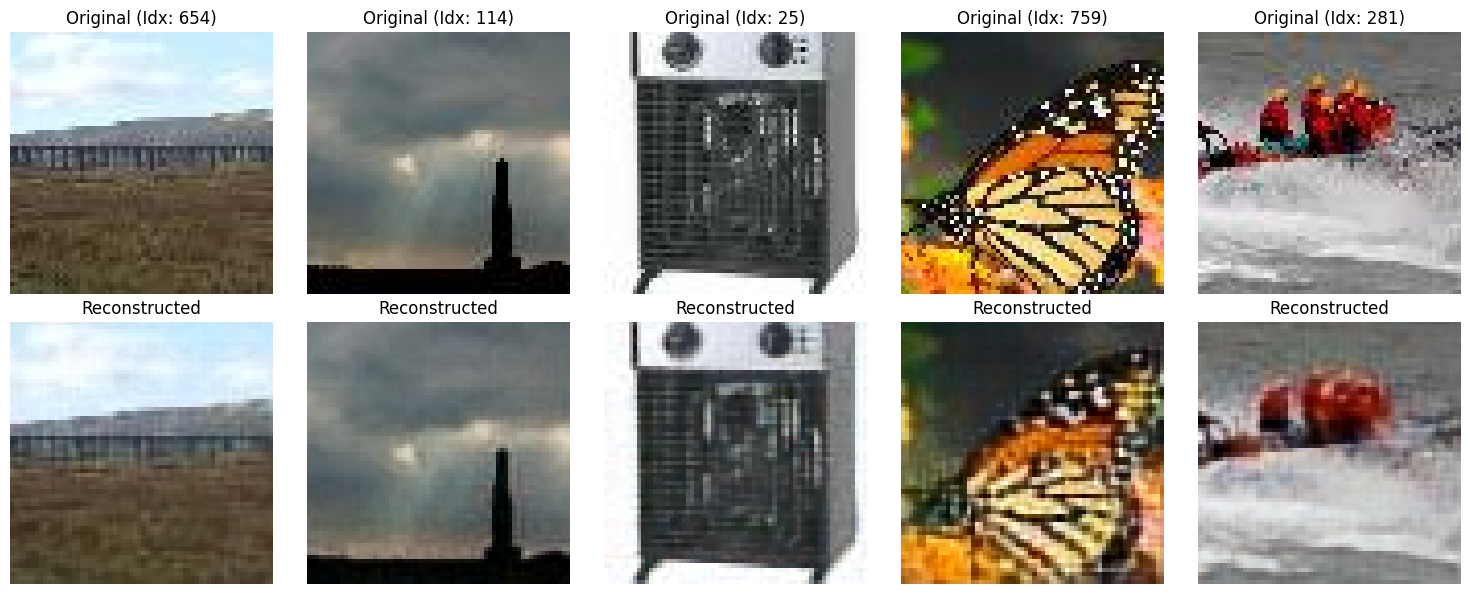

In [21]:
model = CNNAutoencoder()
model.load_state_dict(torch.load("best_autoencoder.pth", map_location=torch.device('cpu')))
model = model.to(device)

# 1. Stack the 5 specific images into a single Batch Tensor
# We use a list comprehension to grab the tensors, then torch.stack to combine them
image_list = [test_dataset_transformed[idx]['pixel_values'] for idx in random_indices]
batch_images = torch.stack(image_list).to(device) # Shape becomes [5, 3, 64, 64]

# 2. Run the Autoencoder (Inference Mode)
model.eval() # Freeze dropout and batchnorm (if any)
with torch.no_grad(): # Disable gradient calculation to save memory
    # Optional: Grab the representation just to verify it works!
    representations = model.encoder(batch_images)
    print(f"Latent Representation Shape: {representations.shape}")

    # Get the reconstructed images
    reconstructions = model(batch_images)

# 3. Prepare Denormalization (Move mean/std to the same device as images)
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)

# Helper function to de-normalize and reshape for Matplotlib
def prep_for_plot(img_tensor):
    img = img_tensor * std + mean
    img = img.cpu().numpy().transpose((1, 2, 0)) # (C, H, W) -> (H, W, C)
    return np.clip(img, 0, 1)

# 4. Plot Originals vs. Reconstructions
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6))

for i in range(5):
    # Top Row: Original Images
    axes[0, i].imshow(prep_for_plot(batch_images[i]))
    axes[0, i].set_title(f"Original (Idx: {random_indices[i]})")
    axes[0, i].axis('off')

    # Bottom Row: Reconstructed Images
    axes[1, i].imshow(prep_for_plot(reconstructions[i]))
    axes[1, i].set_title("Reconstructed")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()